In [1]:
from importlib import reload

import os
from pathlib import Path
# Set the project folder
PRJ_PATH = Path("/Users/admin/Desktop/Monica/PhD")
INC_PATH = os.path.join(PRJ_PATH, "inc")
IMG_PATH = os.path.join(PRJ_PATH, "img")
DATA_PATH = os.path.join(PRJ_PATH, "data")
import sys
# Add to path
if INC_PATH not in sys.path: sys.path.append(INC_PATH)
import argparse
import pandas as pd
from obspy import UTCDateTime
from copy import deepcopy as dcpy

from constants import *
import analyzer as ana
import initializer as ini

args = {
  'channel': None,
  'file': [Path('/Users/admin/Desktop/Monica/PhD/data/manual')],
  'groups': [DATE_STR, NETWORK_STR, STATION_STR],
  'key': None,
  'models': [PHASENET_STR, EQTRANSFORMER_STR],
  'network': [ALL_WILDCHAR_STR],
  'station': [ALL_WILDCHAR_STR],
  'train': False,
  'weights': [INSTANCE_STR, ORIGINAL_STR, STEAD_STR, SCEDC_STR],
  'batch': 4096,
  'config': None,
  'directory': Path('/Users/admin/Desktop/Monica/PhD/data/waveforms'),
  'option': '*',
  'pwave': 0.1,
  'swave': 0.1,
  'client': ['http://158.110.30.217:8080'],
  'denoiser': False,
  'download': False,
  'interactive': False,
  'force': False,
  'pyrocko': False,
  'pyocto': False,
  'timing': False,
  'dates': [UTCDateTime(2023, 6, 1, 0, 0), UTCDateTime(2023, 12, 31, 0, 0)],
  'julian': None,
  'rectdomain': [44, 47.5, 9.5, 15], # [10, 14.5, 44.5, 47]
  'circdomain': None,
  'silent': False,
  'verbose': True
}
args = argparse.Namespace(**args)
DATA_PATH = args.directory.parent

In [2]:
reload(ini)
WAVEFORMS = ini.waveform_table(args)

Reading the Table of Files


In [ ]:
reload(ini)
INVENTORY, STATIONS = ini.station_loader(args, WAVEFORMS)

Min Stations: 95, Max Stations: 145
Total Stations: 151
[Errno 2] No such file or directory: '/Users/admin/Desktop/Monica/PhD/data/station/2Y.A303A.xml'
[Errno 2] No such file or directory: '/Users/admin/Desktop/Monica/PhD/data/station/2Y.A302A.xml'
[Errno 2] No such file or directory: '/Users/admin/Desktop/Monica/PhD/data/station/2Y.A300A.xml'


/Users/admin/Desktop/Monica/PhD/inc/initializer.py:820: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(IMG_FILE, bbox_inches='tight')
/Users/admin/Desktop/Monica/PhD/inc/initializer.py:820: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(IMG_FILE, bbox_inches='tight')


[Text(-25.0, 0, '1969-12-07'), Text(0.0, 0, '1970-01-01'), Text(25.0, 0, '1970-01-26'), Text(50.0, 0, '1970-02-20'), Text(75.0, 0, '1970-03-17'), Text(100.0, 0, '1970-04-11'), Text(125.0, 0, '1970-05-06'), Text(150.0, 0, '1970-05-31'), Text(175.0, 0, '1970-06-25'), Text(200.0, 0, '1970-07-20'), Text(225.0, 0, '1970-08-14')]


Picks Detections
      P     S  Total
0  3995   538   4533
1  1357   607   1964
2  4132  4830   8962
3  1073  1704   2777
4    16    34     50

P        10573
S         7713
Total    18286
dtype: int64

              id                    timestamp  prob PHASE  NETWORK station
1672  2023001035  2023-06-29T15:17:45.250000Z     0     P      NaN    DOSS
1677  2023001035  2023-06-29T15:23:17.370000Z     0     P      NaN    DOSS

              id                    timestamp  prob PHASE  NETWORK station
1670  2023001035  2023-06-29T15:17:43.610000Z     0     P      NaN    GAGG
1675  2023001035  2023-06-29T15:23:15.620000Z     0     P      NaN    GAGG

              id                    timestamp  prob PHASE  NETWORK station
1671  2023001035  2023-06-29T15:17:45.080000Z     0     P      NaN    LUSI
1676  2023001035  2023-06-29T15:23:17.110000Z     1     P      NaN    LUSI

              id                    timestamp  prob PHASE  NETWORK station
1669  2023001035  2023-06-29T15:17:43.030000

/Users/admin/Desktop/Monica/PhD/inc/initializer.py:499: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(IMG_FILE, bbox_inches='tight')
/Users/admin/Desktop/Monica/PhD/inc/initializer.py:499: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(IMG_FILE, bbox_inches='tight')


NameError: cannot access free variable 'INVENTORY' where it is not associated with a value in enclosing scope

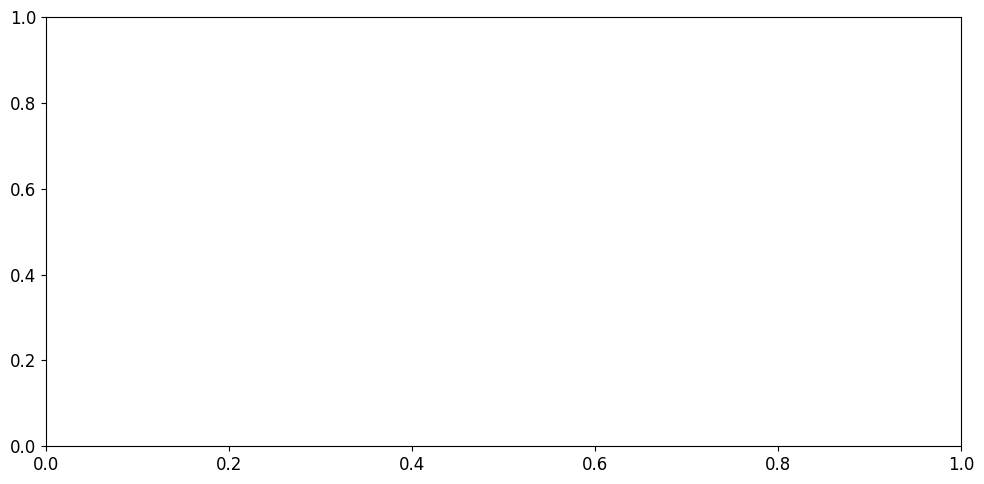

In [ ]:
reload(ini)
TRUE_S, TRUE_D = ini.true_loader(args, WAVEFORMS, INVENTORY, STATIONS)

CLSSFD
Loading /Users/admin/Desktop/Monica/PhD/data/CLSSFD.csv...
Computing the Confusion Matrix
Processing EQTransformer instance...
EQTransformer instance TP: 532
EQTransformer instance FN: 17458
EQTransformer instance FP: 45115
Processing EQTransformer original...
EQTransformer original TP: 409
EQTransformer original FN: 17582
EQTransformer original FP: 9690
Processing EQTransformer scedc...


KeyboardInterrupt: 

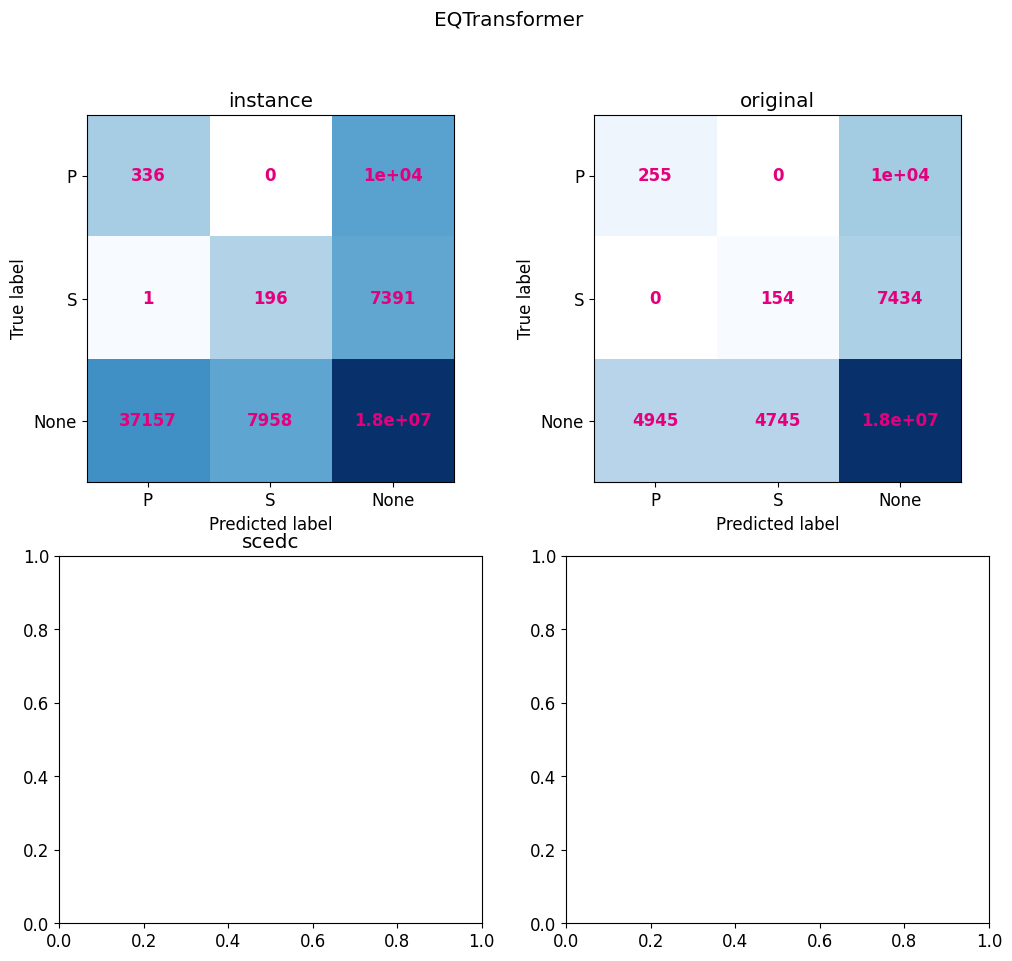

In [10]:
print(CLSSFD_STR)
reload(ana)
PRED = ana._Analysis(args, CLSSFD_STR)
PRED_TP = ana.stat_test(dcpy(TRUE_D), dcpy(PRED), args, CLSSFD_STR)
print(PRED_TP)
ana.time_displacement(PRED_TP, args, CLSSFD_STR)

In [ ]:
print(SOURCE_STR)
PRED_S = ini.data_loader(Path(
  DATA_PATH, ("D_" if args.denoiser else EMPTY_STR) + SOURCE_STR + 
  CSV_EXT))
PRED_S[TIMESTAMP_STR] = PRED_S[TIMESTAMP_STR].apply(lambda x:
                                                    UTCDateTime(x))
ana.time_displacement(ana.stat_test(TRUE_S, PRED_S, args, SOURCE_STR), args,
                  SOURCE_STR)